# **MLB Stuff+ Solution Pipeline**

### **This notebook contains the project problem solution pipeline. The data collected using the data generating scripts will be loaded into a DuckDB database, and used to solve the project problem:**

Using MLB Statcast Data for the 2021-2025 Seasons and Expected Run Values, design a machine learning model to predict the performance of MLB Pitchers based on the quality of their individual pitches in terms of their expected run value, standardized into a normally distributed `Stuff+` value, validating with next-season statistical outcomes.

### **Pipeline Contents**

- Package Imports
- Logging
- Loading Data into DuckDB Database
- Querying Database into Pandas DataFrames
- Pre-Training Feature Engineering
- Model Training
- Model Prediction and Stuff+ Normalization
- Visualization of Results
- Conclusion Based on Visualization

## **Imports**

The following packages are imported for use in the solution pipeline.

In [1]:
# Imports
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import logging
import duckdb

## **Logger Initialization**

This is the initialization of the logger used throughout the pipeline notebook.

In [2]:
# Initializing logger
logging.basicConfig(
    level = logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',  # Timestamp, level, and message format
    filename = 'pipeline.log'                            # Log output file
)
logger = logging.getLogger(__name__)  # Create a logger instance

## **Loading Data into DuckDB Database**

Within the following code chunks, each of the 4 data files are loaded directly into a centralized DuckDB Database.

In [3]:
# Connect to and/or Create DuckDB Database
try:
    con = duckdb.connect(database = 'stuff-plus.db', read_only = False)
    print("Connected to DuckDB instance")
    logger.info("Connected to DuckDB instance")
except Exception as e:
    print(f"Failed to connect to DuckDB instance: {e}")
    logger.error(f"Failed to connect to DuckDB instance: {e}")

# Remove existing tables if they exist from a previous run of the code
try:
    con.execute(f"""
        -- Drop the StatcastPitch table if it exists
        DROP TABLE IF EXISTS StatcastPitch;
                
        -- Drop the PitcherStats table
        DROP TABLE IF EXISTS PitcherStats;
                
        -- Drop the PitcherBio table if it exists
        DROP TABLE IF EXISTS PitcherBio;
                
        -- Drop the ExpectedRunValue table
        DROP TABLE IF EXISTS ExpectedRunValue;   
        """)
    print("Dropped tables if they already existed")
    logger.info("Dropped tables if they already existed")
except Exception as e:
    print(f"Failed to drop existing tables: {e}")
    logger.error(f"Failed to drop existing tables: {e}")

# Load the data files into the Database
try:
    # Loading in the StatcastPitch data
    con.execute(f"""
        -- Create the StatcastPitch table
                CREATE TABLE StatcastPitch
                AS
                Select * FROM read_parquet('data/statcast-data.parquet');
        """)
    print("Loaded StatcastPitch Table")
    logger.info("Loaded StatcastPitch Table")

    # Loading in the PitcherStats data
    con.execute(f"""
        -- Create the PitcherStats table
                CREATE TABLE PitcherStats
                AS
                Select * FROM read_parquet('data/pitcher-stats.parquet');
        """)
    print("Loaded PitcherStats Table")
    logger.info("Loaded PitcherStats Table")

    # Loading in the PitcherBio data
    con.execute(f"""
        -- Create the PitcherBio table
                CREATE TABLE PitcherBio
                AS
                Select * FROM read_parquet('data/pitcher-bio.parquet');
        """)
    print("Loaded PitcherBio Table")
    logger.info("Loaded PitcherBio Table")

    # Loading in the ExpectedRunValue data
    con.execute(f"""
        -- Create the ExpectedRunValue table
                CREATE TABLE ExpectedRunValue
                AS
                Select * FROM read_parquet('data/run-values.parquet');
        """)
    print("Loaded ExpectedRunValue Table")
    logger.info("Loaded ExpectedRunValue Table")
except Exception as e:
    print(f"Failed to load data into DuckDB: {e}")
    logger.error(f"Failed to load data into DuckDB: {e}")

Connected to DuckDB instance
Dropped tables if they already existed


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded StatcastPitch Table
Loaded PitcherStats Table
Loaded PitcherBio Table
Loaded ExpectedRunValue Table


## **Querying Database into Pandas DataFrames**

Within the following code chunks, the data tables will be queried out of the DuckDB database into Pandas DataFrames, which will be used for the modeling/analysis stage. The following DataFrames will be queried:

- **model_df:** A join between the StatcastPitch and ExpectedRunValue tables, to be used for feature engineering and model training
- **bio_df**: The PitcherBio table, to be used for analysis/visualization
- **stats_df**: The PitcherStats table, to be used for analysis/visualization

In [4]:
# Query tables into pandas dataframes
try:
    # Query model_df DataFrame
    model_df = con.execute("""
        SELECT 
            s.*,                                                    -- All columns of StatcastPitch
            e.delta_run_exp AS target                               -- delta_run_exp from ExpectedRunValue as the model target variable
        FROM StatcastPitch s
        LEFT JOIN ExpectedRunValue e
            ON s.event_balls_strikes = e.event_balls_strikes;       -- Left join on the event_balls_strikes column
    """).fetchdf()
    print(f"Extracted model_df")
    logger.info(f"Extracted model_df")

    # Query bio_df DataFrame
    bio_df = con.execute("""
        SELECT * FROM PitcherBio;
        """).fetchdf()
    print(f"Extracted bio_df")
    logger.info(f"Extracted bio_df")

    # Query stats_df DataFrame
    stats_df = con.execute("""
        SELECT * FROM PitcherStats;
        """).fetchdf()
    print(f"Extracted stats_df")
    logger.info(f"Extracted stats_df")

except Exception as e:
    print(f"Failed to query tables into DataFrames: {e}")
    logger.error(f"Failed to query tables into DataFrames: {e}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extracted model_df
Extracted bio_df
Extracted stats_df


## **Pre-Training Feature Engineering**

Within the following code chunks, feature engineering will be conducted. Explanations/justifications for the feature engineering decisions are included in the corresponding markdown chunks.

**Horizontal Feature Mirroring**

The StatcastPitch dataset contains pitches from both right-handed and left-handed pitchers. If features pertaining to horizontal location/movement are inserted into the model, their effects will be opposing based on handedness. For example, a -15 inch break for a lefty and a 15 inch break for a righty arise out of the same pitch type and have similar effects on batters, however, a model will view these values as polar opposite. As such, horizontal features must be mirrored. The following code chunk mirrors horizontal features for every left-handed pitch in the dataset, effectively modeling every pitch as coming from a right-handed pitcher.

In [5]:
# Horizontal features (Horizontal break and release point)
horizontal_features = ['pfx_x', 'release_pos_x']

# Loop through each feature and mirror the effects
for hf in horizontal_features:
    model_df.loc[model_df['p_throws'] == 'L', hf] = -1 * model_df.loc[model_df['p_throws'] == 'L', hf]
print("Mirrored Horizontal Features for Lefties")
logger.info("Mirrored Horizontal Features for Lefties")

Mirrored Horizontal Features for Lefties


**Adding Fastball Difference Features**

One of the well-understood principles of pitching is that throwing pitches with different velocities and directions than fastballs (the most common pitch) is beneficial. If a pitcher throws a 95 mph fastball and a 78 mph change-up, hitters find it much more challenging to correctly time their swings on either, due to the large gap in velocities. In order to include this principle in the model, the difference between the velocity, horizontal break, and vertical break of each pitch from that of a pitcher's average fastball will be added to the model in the following code chunk. For pitchers who do not throws any fastballs, the pitch with the maximum velocity will be treated as their reference pitch when calculating differences.

In [6]:
# Pitch types to consider as fastballs (4-Seam Fastball, Cutter, Sinker)
fastballs = ['FF', 'FC', 'SI']

# Create filtered DataFrame for only fastballs
fb_df = model_df[model_df['pitch_type'].isin(fastballs)]

# Group by pitcher, season, and pitch type
    # Calculate average velocity, horizontal break, vertical break and number of times thrown
fb_agg = fb_df.groupby(['pitcher_season', 'pitch_type']).agg(
    average_fb_speed = ('release_speed', 'mean'),
    average_fb_hb = ('pfx_x', 'mean'),
    average_fb_vb = ('pfx_z', 'mean'),
    n_pitches = ('pitch_type', 'count')
).reset_index()

# Sort by number of times thrown and average fastball speed, keep the first for each pitcher_season
fb_agg = fb_agg.sort_values(by = ['n_pitches', 'average_fb_speed'], ascending = [False, False])
fb_agg = fb_agg.drop_duplicates(subset = ['pitcher_season'], keep = 'first')

In [7]:
# Join this aggregated DataFrame to the model_df DataFrame
model_df = model_df.merge(fb_agg, on = 'pitcher_season', how = 'left')

# Get the fastest pitch per pitcher_season
fastest_pitch = model_df.loc[
    model_df.groupby('pitcher_season')['release_speed'].idxmax(),
    ['pitcher_season', 'release_speed', 'pfx_x', 'pfx_z']].rename(columns = {
    'release_speed': 'fastest_speed',
    'pfx_x': 'fastest_pfx_x',
    'pfx_z': 'fastest_pfx_z'
})

# Merge in the fastest pitch values
model_df = model_df.merge(fastest_pitch, on = 'pitcher_season', how = 'left')

In [8]:
# Fill values for pitchers who never threw a fastball with the fastest pitch values for speed, horizontal break, and vertical break
model_df['average_fb_speed'] = model_df['average_fb_speed'].where(
    model_df['average_fb_speed'].notna(), model_df['fastest_speed']
)
model_df['average_fb_hb'] = model_df['average_fb_hb'].where(
    model_df['average_fb_hb'].notna(), model_df['fastest_pfx_x']
)
model_df['average_fb_vb'] = model_df['average_fb_vb'].where(
    model_df['average_fb_vb'].notna(), model_df['fastest_pfx_z']
)

# Drop the columns used for this calculation
model_df = model_df.drop(columns = ['n_pitches', 'fastest_speed', 'fastest_pfx_x', 'fastest_pfx_z'])

In [9]:
# Calculate differences
model_df['release_speed_diff'] = model_df['release_speed'] - model_df['average_fb_speed']
model_df['pfx_z_diff'] = model_df['pfx_z'] - model_df['average_fb_vb']
model_df['pfx_x_diff'] = (model_df['pfx_x'] - model_df['average_fb_hb']).abs()

In [10]:
print("Completed Feature Engineering")
logger.info("Completed Feature Engineering")

Completed Feature Engineering


**Model Feature Selection**

There are numerous features in the model_df DataFrame that could be used in this model. However, best practice is to keep Stuff+ models relatively simple, in order to preserve their interpretability. As such, this model will make use of only a select number of features, which are listed below, along with their justifications.

- `release_speed` — Velocity is one of the strongest individual predictors of pitch success
- `release_extension` — Extension shortens the distance to the plate, reducing hitter reaction time independent of velocity
- `release_spin_rate` — Spin rate drives movement magnitude and can increase or decrease a pitch's effectiveness depending on type
- `spin_axis` — Axis direction determines the plane of movement, distinguishing sweeping break from ride or sink
- `pfx_x` — Horizontal break is a primary characteristic differentiating pitch types
- `pfx_z` — Vertical break similarly defines pitch shape and is important for inducing weak contact or whiffs
- `release_speed_diff` — Velocity separation from a pitcher's fastball is key to disrupting hitter timing
- `pfx_x_diff` — Horizontal break differential creates deception by differing from the expected path of the ball
- `pfx_z_diff` — Vertical break differential similarly disrupts timing by altering the expected flight path


## **Model Training**

Within the following code chunks, the Histogram Gradient Boosting Decision Tree model will use the aforementioned features to predict the expected run value delta for each pitch across the entire dataset. No train-test split is used, as the goal is not to evaluate generalization to unseen data, but rather to learn the average relationship between pitch characteristics and run value outcomes. Each pitch will be then scored against this learned mapping, in order to produce a normalized, interpretable quality metric. If the model is well-trained, this quality metric, `Stuff+`, will better predict future performance than traditional metrics.

In [11]:
# List of features
features = ['release_speed',
            'release_extension',
            'release_spin_rate',
            'spin_axis',
            'pfx_x',
            'pfx_z',
            'release_speed_diff',
            'pfx_x_diff',
            'pfx_z_diff']

# Drop rows with null feature or target values
model_df = model_df.dropna(subset = features + ['target'])

# Split into X (features) and y (target) DataFrames
X = model_df[features]
y = model_df['target']

# Make model with Histogram Gradient Boosting Decision Tree
model = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_depth = 5,
    min_samples_leaf = 20,
    l2_regularization = 0.05,
    random_state = 0
)

# Fit Model
model.fit(X, y)

print("Finished Training Model")
logger.info("Finished Training Model")

Finished Training Model


## **Model Prediction and Stuff+ Normalization**

In the following code chunks, the model will be used to predict the delta_run_exp of every pitch in the dataset, based on the relationships learned from training the model. This raw prediction score will then be mapped onto a normal distribution with a mean of 100, and a standard deviation of 10. Under this mapping, values above 100 refer to above average pitches, and values below 100 refer to below average pitches. This mapping is the industry standard method for quantifying Stuff+. It is designed to mimic the MLB scouting scale, which likewise models player ability on a normal distribution with a standard deviation fo 10, albeit with a mean of 50, not 100.


In [12]:
# Get predictions on full dataset
model_df['raw_prediction'] = model.predict(X)

# Normalize to Stuff+ scale (mean 100, std 10)
mean_pred = model_df['raw_prediction'].mean()
std_pred = model_df['raw_prediction'].std()

# Calculate Stuff+
    # Note: z-score is negated, as negative predicted delta_exp_run is the good outcome for pitchers
    # This will make above 100 better than average, and below 100 worse than average
model_df['stuff_plus'] = 100 + ((mean_pred - model_df['raw_prediction']) / std_pred) * 10

print("Calculated Stuff+")
logger.info("Calculated Stuff+")

Calculated Stuff+


## **Visualization of Results**

This section will visualize the results in multiple ways, including a distribution of Stuff+ by pitch type, a visualization of Stuff+ as a function of biological features, and finally a visualization of how current year Stuff+ correlates with next year Earned Run Average. The final visualization will be used to determine whether the Stuff+ model has learned how to forecast future results better than traditional metrics. 

</br>

#### **Note: The final visualization is the one designed to meet the rubric and serve as the solution for the project problem.**

</br>


**Stuff+ Distribution by Pitch Type**

The reason for this visualization is to better understand the value of specific pitch types. By examining the Stuff+ distributions for the most commonly thrown pitches, we can begin to understand the value of specific pitches.

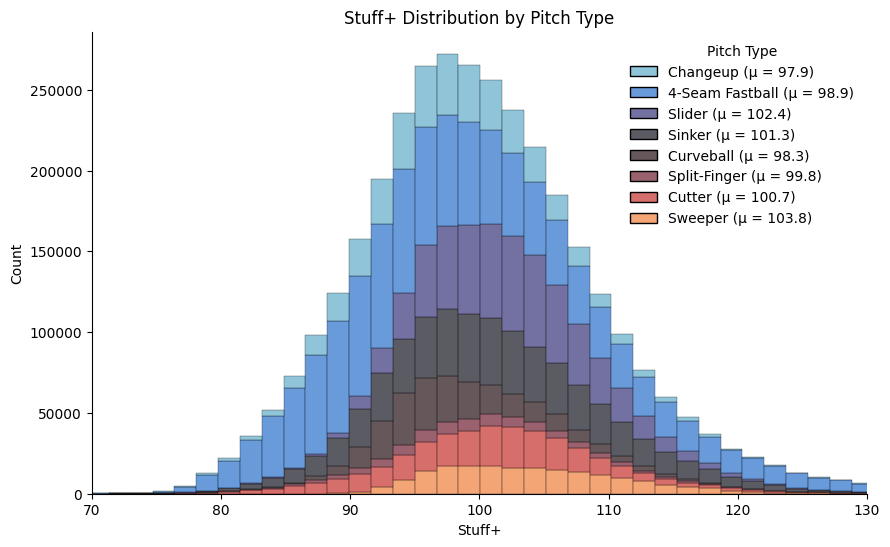

In [ ]:
# Get the 8 most thrown pitch types
top_pitches = model_df['pitch_name'].value_counts().nlargest(8).index

# Calculate mean stuff+ per pitch type for legend labels
pitch_means = model_df[model_df['pitch_name'].isin(top_pitches)].groupby('pitch_name')['stuff_plus'].mean()
label_map = {pitch: f"{pitch} (μ = {mean:.1f})" for pitch, mean in pitch_means.items()}

# Remap pitch_name to include mean in label
plot_df = model_df[model_df['pitch_name'].isin(top_pitches)].copy()
plot_df['pitch_name'] = plot_df['pitch_name'].map(label_map)

# Initialize figure
plt.figure(figsize = (10, 6))

# Stacked Histogram Plot
ax = sns.histplot(data = plot_df, x = 'stuff_plus', hue = 'pitch_name', bins = 250, multiple = 'stack', palette = 'icefire')

# Despine
sns.despine(top = True, right = True)

# Set x-limits
plt.xlim(70, 130)

# Legend
ax.legend_.set_title('Pitch Type')
ax.legend_.set_frame_on(False)

# Title and x-axis
ax.set_title("Stuff+ Distribution by Pitch Type")
ax.set_xlabel("Stuff+")

# Show plot
plt.savefig('./img/stuff_plus_by_pitch_type.png')
plt.show()

print("Created Stuff+ Distribution Plot")
logger.info("Created Stuff+ Distribution Plot")

**Stuff+ as a Function of Height and Weight**

The purpose of this visualization is to uncover whether there exists relationships between biological characteristics like height and weight, and Stuff+.

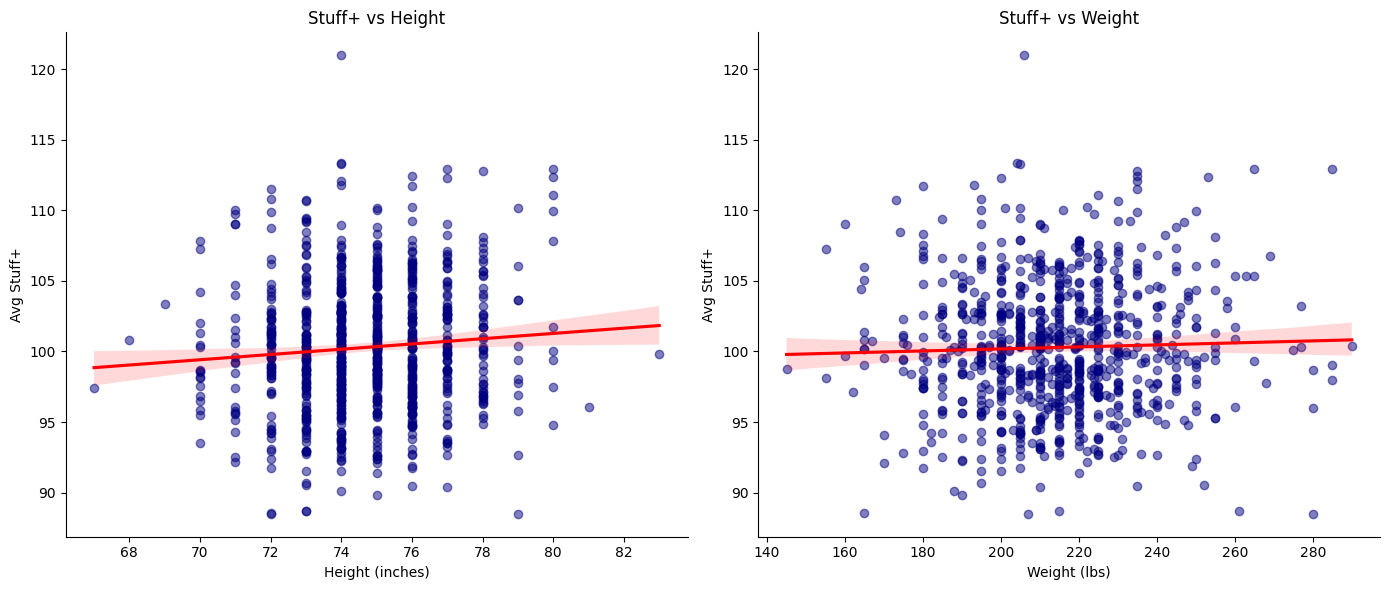

In [ ]:
# Get average Stuff+ by pitcher
avg = model_df.groupby('pitcher').agg(
    avg_stuff_plus = ('stuff_plus', 'mean'),
    n_pitches = ('stuff_plus', 'count')
).reset_index()

# Limit to pitchers with 1000+ pitches thrown, and merge with the PitcherBio DataFrame
avg_bio = avg[avg['n_pitches'] >= 1000].merge(bio_df, left_on = 'pitcher', right_on = 'pitcherID', how = 'inner')

# Convert height from ft" in' to inches
avg_bio['height_inches'] = (
    avg_bio['height'].str.replace('"', '').str.strip().str.split("'").str[0].astype(int) * 12 +
    avg_bio['height'].str.replace('"', '').str.strip().str.split("'").str[1].astype(int)
)

# Initialize figure with two side-by-side axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

# Height plot
sns.regplot(data = avg_bio, x = 'height_inches', y = 'avg_stuff_plus', ax = ax1,
            scatter_kws = {'alpha': 0.5, 'color': 'navy'}, line_kws = {'color': 'red'})

# Despine, axis labels, title
sns.despine(ax = ax1, top = True, right = True)
ax1.set_xlabel('Height (inches)')
ax1.set_ylabel('Avg Stuff+')
ax1.set_title('Stuff+ vs Height')

# Weight plot
sns.regplot(data = avg_bio, x = 'weight', y = 'avg_stuff_plus', ax = ax2,
            scatter_kws = {'alpha': 0.5, 'color': 'navy'}, line_kws = {'color': 'red'})

# Despine, axis labels, title
sns.despine(ax = ax2, top = True, right = True)
ax2.set_xlabel('Weight (lbs)')
ax2.set_ylabel('Avg Stuff+')
ax2.set_title('Stuff+ vs Weight')

# Show plot
plt.tight_layout()
plt.savefig('./img/stuff_plus_vs_height_and_weight')
plt.show()

print("Created Stuff+ Biographical Plot")
logger.info("Created Stuff+ Biographical Plot")

**Next Year ERA vs Current Year Stuff+**

This visualization serves as the ultimate test of the project's specific problem, examining whether Stuff+ better predicts future outcomes than traditional metrics. It compares the correlation between current season Stuff+ and next season ERA against the year-over-year correlation of ERA itself. ERA was chosen as the benchmark as it is the most widely understood pitching metric, simplifying performance into a single number representing the rate at which a pitcher allows runs. If Stuff+ correlates more strongly with future ERA than current ERA does, it is reasonable to conclude that pitch quality is a more stable signal of true pitcher ability, and that this model improves upon the predictability of future success.

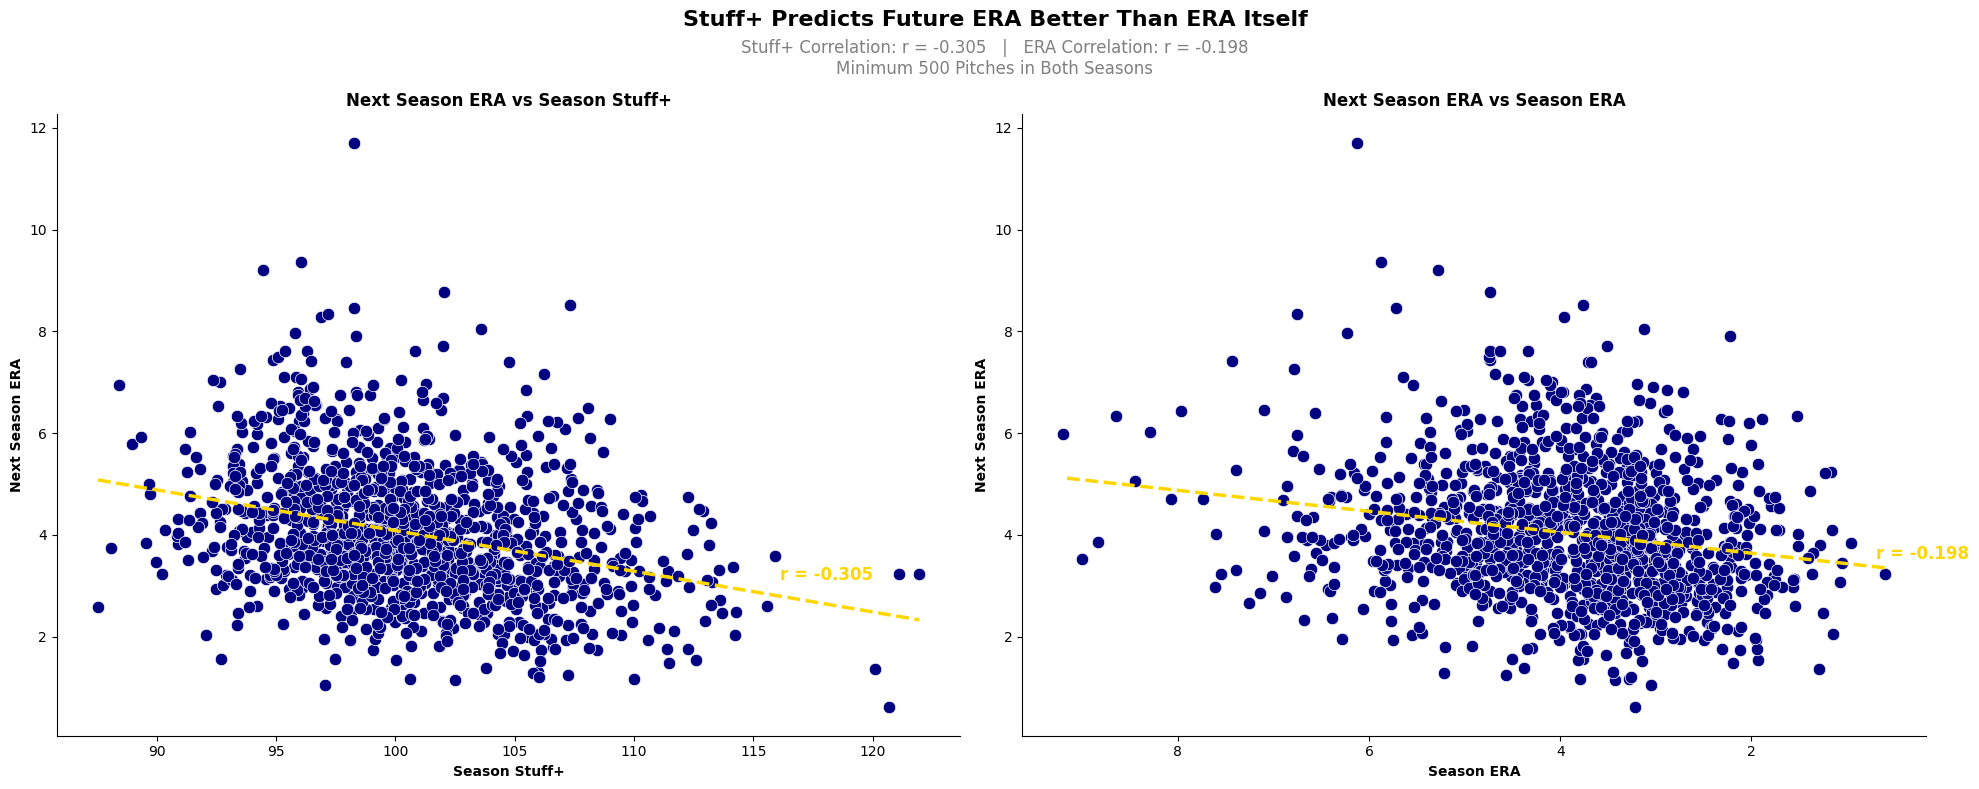

In [ ]:
# Get total pitches per pitcher_season for filtering
pitch_counts = model_df.groupby('pitcher_season')['stuff_plus'].count().reset_index(name = 'total_pitches')

# Get average stuff+ by pitcher_season and pitch type
avg_by_season = model_df.groupby(['pitcher_season', 'pitch_type_x']).agg(
    avg_stuff_plus = ('stuff_plus', 'mean'),
    n_pitches = ('stuff_plus', 'count')
).reset_index()

# Limit to pitchers with 500+ total pitches thrown
valid_seasons = pitch_counts[pitch_counts['total_pitches'] >= 500]['pitcher_season']
avg_by_season = avg_by_season[avg_by_season['pitcher_season'].isin(valid_seasons)]

# Calculate weighted average based on number of pitches
avg_by_season = avg_by_season.groupby('pitcher_season').apply(
    lambda x: np.average(x['avg_stuff_plus'], weights = x['n_pitches']),
    include_groups = False
).reset_index(name = 'avg_stuff_plus')

# Merge with PlayerStats DataFrame
stats_stuff = avg_by_season.merge(stats_df, left_on = 'pitcher_season', right_on = 'pitcherID_Season', how = 'inner')

# Create S0 and S1 pairs for consecutive seasons
result_rows = []

# Loop through pitchers
for pitcher in stats_stuff['PlayerName'].unique():
    # Limit to pitcher, sort by season
    pitcher_data = stats_stuff[stats_stuff['PlayerName'] == pitcher].sort_values(by = 'Season')

    # Get consecutive season pairs
    for i in range(len(pitcher_data) - 1):
        s0_row = pitcher_data.iloc[i]
        s1_row = pitcher_data.iloc[i + 1]

        # Create pair if the seasons are consecutive
        if s1_row['Season'] - s0_row['Season'] == 1:
            result_rows.append({
                'PlayerName': pitcher,
                'S0_Season': s0_row['Season'],
                'S0_stuff_plus': s0_row['avg_stuff_plus'],
                'S0_ERA': s0_row['ERA'],
                'S0_FIP': s0_row['FIP'],
                'S0_IP': s0_row['IP'],
                'S0_Pitches': s0_row['Pitches'],
                'S1_Season': s1_row['Season'],
                'S1_stuff_plus': s1_row['avg_stuff_plus'],
                'S1_ERA': s1_row['ERA'],
                'S1_FIP': s1_row['FIP'],
                'S1_IP': s1_row['IP'],
                'S1_Pitches': s1_row['Pitches']
            })

paired = pd.DataFrame(result_rows)

# Initialize figure
fig, ax = plt.subplots(1, 2, figsize = (20, 8))

# MAKING PLOT 1 (ERA VS STUFF+)

# Calculate correlation
stuff_corr = paired['S0_stuff_plus'].corr(paired['S1_ERA'])

# Scatterplot
ax[0].scatter(paired['S0_stuff_plus'], paired['S1_ERA'], s = 80, color = 'navy', edgecolors = 'white', linewidth = 0.5)

# Best fit line
z_stuff = np.polyfit(paired['S0_stuff_plus'], paired['S1_ERA'], 1)
p_stuff = np.poly1d(z_stuff)
x_line_stuff = np.linspace(paired['S0_stuff_plus'].min(), paired['S0_stuff_plus'].max(), 100)
ax[0].plot(x_line_stuff, p_stuff(x_line_stuff), color = 'gold', linestyle = '--', linewidth = 2.5)
ax[0].text(0.8, 0.25, f'r = {stuff_corr:.3f}', transform = ax[0].transAxes,
           color = 'gold', fontsize = 12, fontweight = 'bold')

# Formatting
ax[0].set_xlabel('Season Stuff+', fontweight = 'bold')
ax[0].set_ylabel('Next Season ERA', fontweight = 'bold')

# Title
ax[0].set_title('Next Season ERA vs Season Stuff+', fontweight = 'bold')

# Despine
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# MAKING PLOT 2 (ERA VS ERA)

# Calculate correlation
era_corr = -1 * paired['S0_ERA'].corr(paired['S1_ERA'])

# Scatterplot
ax[1].scatter(paired['S0_ERA'], paired['S1_ERA'], s = 80, color = 'navy', edgecolors = 'white', linewidth = 0.5)

# Best fit line
z_era = np.polyfit(paired['S0_ERA'], paired['S1_ERA'], 1)
p_era = np.poly1d(z_era)
x_line_era = np.linspace(paired['S0_ERA'].min(), paired['S0_ERA'].max(), 100)
ax[1].plot(x_line_era, p_era(x_line_era), color = 'gold', linestyle = '--', linewidth = 2.5)
ax[1].text(0.945, 0.285, f'r = {era_corr:.3f}', transform = ax[1].transAxes,
           color = 'gold', fontsize = 12, fontweight = 'bold')

# Formatting
ax[1].set_xlabel('Season ERA', fontweight = 'bold')
ax[1].set_ylabel('Next Season ERA', fontweight = 'bold')

# Title
ax[1].set_title('Next Season ERA vs Season ERA', fontweight = 'bold')

# Despine
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# Invert x-axis
ax[1].invert_xaxis()

# Figure Wide Formatting
fig.suptitle('Stuff+ Predicts Future ERA Better Than ERA Itself', fontweight = 'bold', fontsize = 16)
fig.text(0.5, 0.9, f'Stuff+ Correlation: r = {stuff_corr:.3f}   |   ERA Correlation: r = {era_corr:.3f}\nMinimum 500 Pitches in Both Seasons', 
         ha = 'center', fontsize = 12, color = 'gray')
plt.tight_layout(rect = [0, 0, 1, 0.94])

# Show plot
plt.savefig('./img/stuff_plus_correlation_plot.png')
plt.show()

print("Created Stuff+ Correlation Plot")
logger.info("Created Stuff+ Correlation Plot")

#### **Conclusion Based on Visualization(s)**

The results support the project's objective. With a correlation of r = -0.305 between current season `Stuff+` and next season ERA, compared to r = -0.198 for ERA itself, `Stuff+` demonstrates a meaningfully stronger relationship with future performance. While neither metric is a strong standalone predictor, due to the inherently noisy nature of outcomes in baseball, the improvement in correlation suggests that the `Stuff+` model captures the true pitcher ability to a degree that ERA alone is unable to do.